# Exploratory Data Analysis (EDA)

This section explores the dataset structure and examines the various data types we will be working with. It also identifies potential inconsistencies, and sets initial data cleaning steps we'll take throughout the project. And gives initial insights into the data we will be working with.

## Import Libraries and Load Dataset

In [30]:
# Import Libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Load Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# View Data
df.head(10)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,None,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,None,NaN,NaN,"Miracle Software Systems, Inc","[sql, python, java, sql server, gcp, bigquery,...","{'cloud': ['gcp', 'bigquery'], 'databases': ['..."
7,Data Engineer,Data Engineer,Anywhere,via LinkedIn,Full-time,True,Romania,2023-12-07 13:40:49,False,False,Romania,None,NaN,NaN,Zitec,"[sql, nosql, gcp, azure, aws, bigquery, databr...","{'cloud': ['gcp', 'azure', 'aws', 'bigquery', ..."
8,Business Analyst,Technology & Operations Business Analyst,"Copenhagen, Denmark",via Trabajo.org,Full-time,False,Denmark,2023-06-05 13:44:34,False,False,Denmark,None,NaN,NaN,Hempel,"[excel, powerpoint, power bi]","{'analyst_tools': ['excel', 'powerpoint', 'pow..."
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,None,NaN,NaN,"Radwell International, LLC","[sql, python, r, mongodb, mongodb, sql server,...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."


## Demand of Job Roles Across the Data Industry

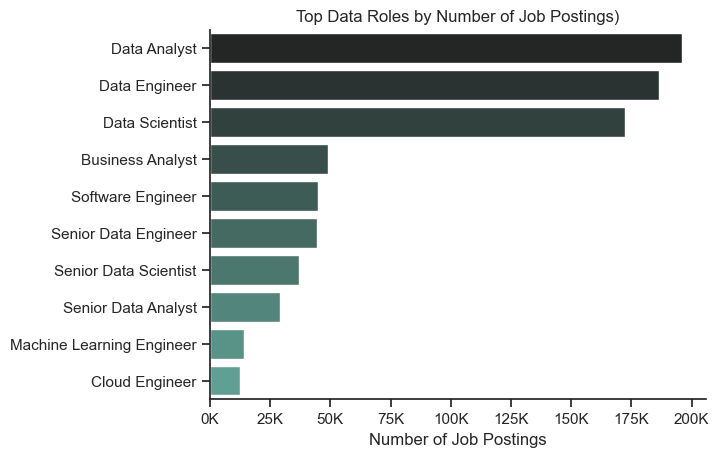

In [41]:
# Build Data
job_title_count = df["job_title_short"].value_counts().to_frame()

# Plot and Visualize
sns.set_theme(style='ticks')
sns.barplot(data=job_title_count, x='count', y='job_title_short', palette='dark:#5A9', hue='job_title_short')
sns.despine()

plt.title('Top Data Roles by Number of Job Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.show()


The most significant data roles are Data Analyst, Data Engineer, and Data Scientist, with job postings far surpassing other specialized data roles by more than 100K in count. Their dominance highlights their foundational importance in organizations, with senior counterparts (e.g., Senior Data Scientist) only representing about 1/4 of their junior roles. Specialized roles like Machine Learning Engineer and Cloud Engineer fall below 20K job postings, indicating niche but put possibly growing areas (about 1/10th the availability of the top 3 roles).

## Geographic Demand of Job Opportunities in the Data Industry

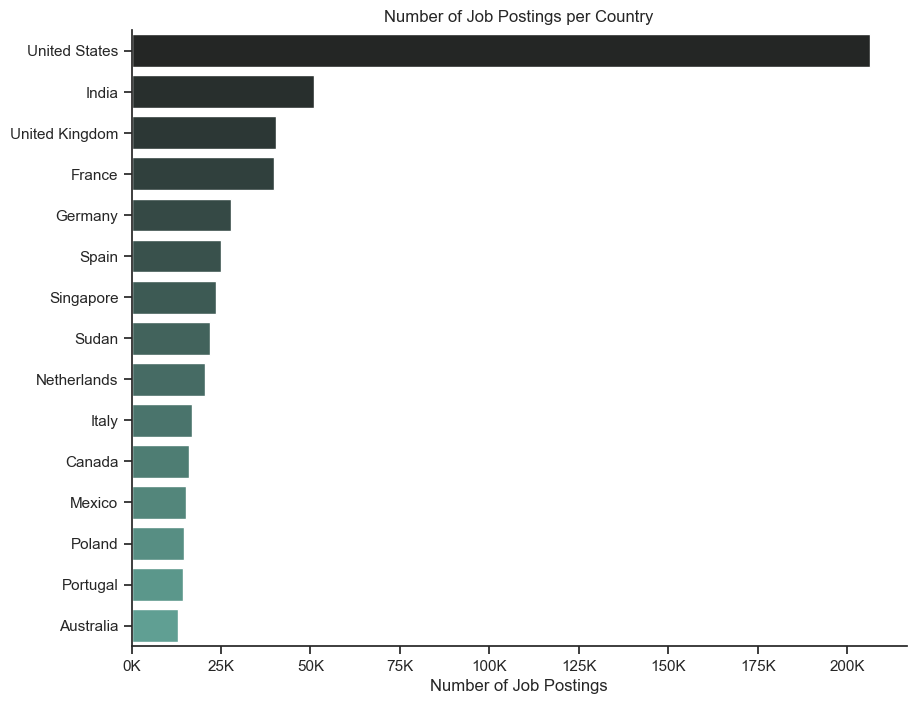

In [39]:
# Build Data
job_title_count = df["job_country"].value_counts().head(15).reset_index()
job_title_count.columns = ['job_country', 'count']

# Plot and Visualize
plt.figure(figsize=(10, 8))
sns.set_theme(style='ticks')
sns.barplot(data=job_title_count, x='count', y='job_country', palette='dark:#5A9', hue='job_country')
sns.despine()

plt.title('Number of Job Postings per Country')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.show()

The United States leads significantly in job postings. This may be influenced by data collection bias. However, this dominance may also reflect high market productivity and a thriving tech sector or data-driven businesses in the US. Europe contributes 8 out of the top 15 countries, demonstrating its robust demand for data professionals. India ranks as the top contributor in Asia, followed by Singapore, reflecting the leading tech hubs in Asia. Other notable contributors include Sudan (Africa) and Australia (Oceania), along with the other North American countries, Canada and Mexico.

## Leading Employers in the Data Industry

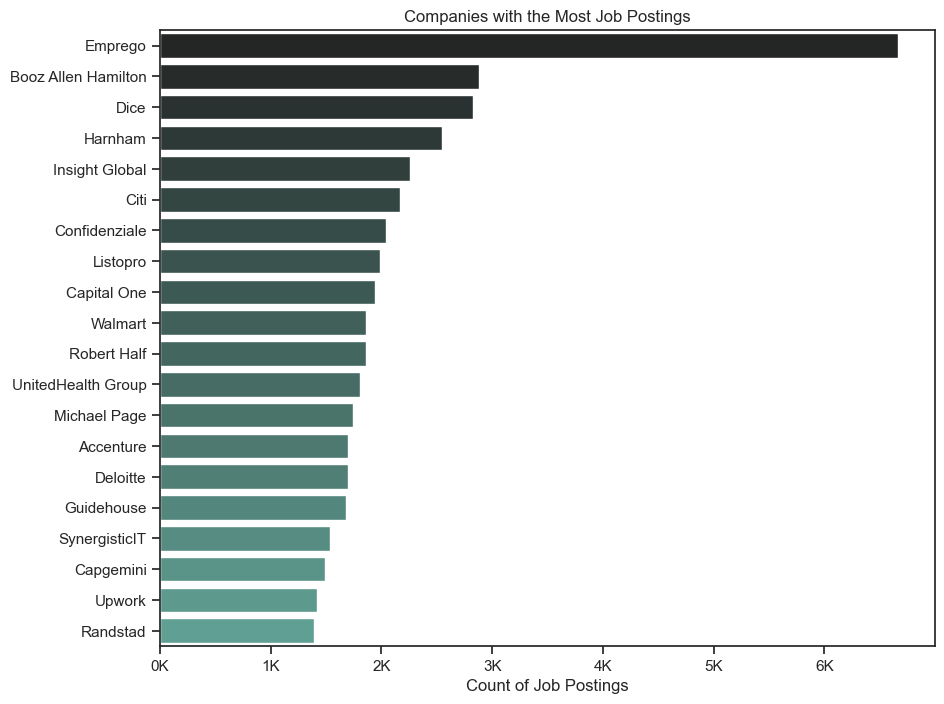

In [42]:
# Build Data
job_title_count = df["company_name"].value_counts().head(20).reset_index()

# Plot and Visualize
plt.figure(figsize=(10, 8))
sns.set_theme(style='ticks')
sns.barplot(data=job_title_count, x='count', y='company_name', palette='dark:#5A9', hue='company_name', legend=False)
sns.despine

plt.title('Companies with the Most Job Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.show()

Emprego significantly outpaces all other companies, but further investigation reveals it functions as a job aggregator or bulk recruiter rather than an individual employer. Prominent recruiters like Booz Allen Hamilton and Harnham rank highly, showcasing their strong focus on data talent acquisition. Companies in consulting (Booz Allen, Deloitte, Accenture) and recruitment platforms (Dice, Insight Global) are prominent, reflecting a consistent demand for data professionals. Meanwhile, Walmart, Capital One, and UnitedHealth Group emphasize the increasing integration of data-driven decision-making in retail, finance, and healthcare sectors.

## Employment Types in Data Positions

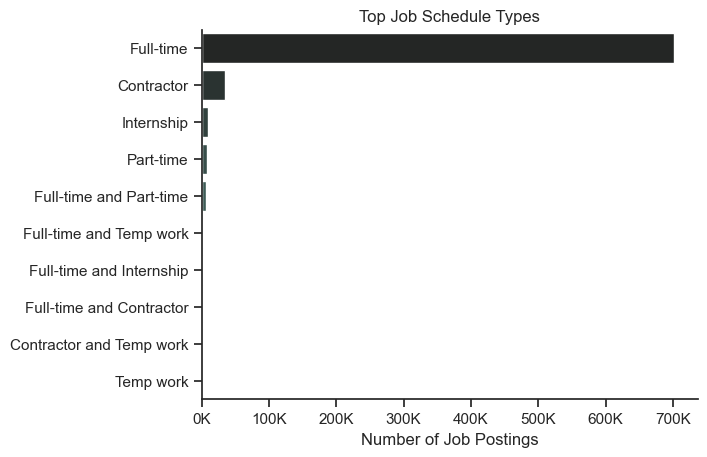

In [45]:

# Prepare Data
df_exploded = df.explode('job_schedule_type')

# Build Data
schedule_type = df_exploded['job_schedule_type'].value_counts().head(10).reset_index()

# Plot and Visualize
sns.set_theme(style='ticks')
sns.barplot(data=schedule_type, x='count', y='job_schedule_type', palette='dark:#5A9', hue='job_schedule_type')
sns.despine()

plt.title('Top Job Schedule Types')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.show()

Despite the rise of the gig economy and remote work, full-time roles continue to dominate, accounting for around 700K job postings. This highlights the structured, permanent nature of data roles in most organizations, where companies seek long-term employment to support ongoing data needs.

## Workplace Flexibility, Degree Requirements, and Benefits Analysis

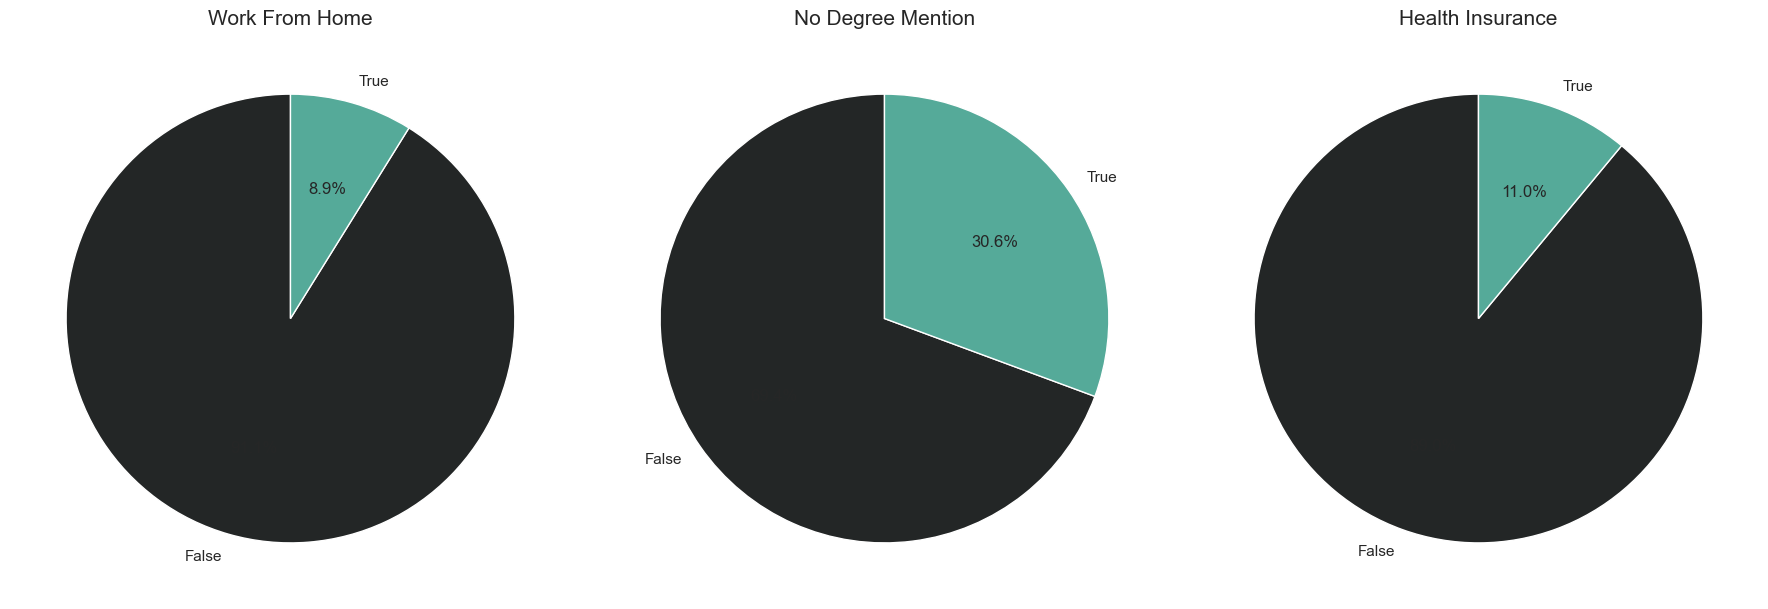

In [51]:
# Prepare Data
work_from_home = df['job_work_from_home'].value_counts()
degree_mention = df['job_no_degree_mention'].value_counts()
health_insurance = df['job_health_insurance'].value_counts()

# Prepare Plot
colors = sns.color_palette('dark:#5A9', len(work_from_home))
fig, ax = plt.subplots(1, 3, figsize=(18,6))

# Pie Chart 1: Work From Home
ax[0].pie(work_from_home.values, labels=work_from_home.index, autopct='%1.1f%%', startangle=90, colors=colors)
ax[0].set_title('Work From Home', fontsize=15, pad=10)

# Pie Chart 2: No Degree Mention
ax[1].pie(degree_mention.values, labels=degree_mention.index, autopct='%1.1f%%', startangle=90, colors=colors)
ax[1].set_title('No Degree Mention', fontsize=15, pad=10)

# Pie Chart 3: Health Insurance
ax[2].pie(health_insurance.values, labels=health_insurance.index, autopct='%1.1f%%', startangle=90, colors=colors)
ax[2].set_title('Health Insurance', fontsize=15, pad=10)

plt.tight_layout()
plt.show()

Only 9% of job postings explicitly mention work-from-home opportunities, reinforcing the full-time, in-office culture of data roles. Additionally, 89% of job postings do not mention health insurance benefits, suggesting either an assumption of default coverage or a lack of detailed benefit listings. Meanwhile, 70% of job listings still require a degree, showing that traditional educational credentials remain a key requirement, although evolving job markets may reduce this dependency in the future.